In [3]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import scipy.optimize as opt
import matplotlib.pyplot as plt
import seaborn as sns
from pyglam import *

In [4]:
# Estilo acadêmico padronizado para as figuras
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.linewidth': 1.4,
    'lines.linewidth': 2.0,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 5,
    'ytick.major.size': 5,

})

In [5]:
# Funções utilitárias seguras para a GLD (necessárias para as Tabelas e Figuras de Diagnóstico)
def safe_gld_cdf(dist, x, tol=1e-10):
    x = np.atleast_1d(np.asarray(x, dtype=float))
    q_low = dist.ppf(tol)
    q_high = dist.ppf(1.0 - tol)
    res = np.zeros_like(x)
    for i, xi in enumerate(x):
        if xi <= q_low:
            res[i] = 0.0
        elif xi >= q_high:
            res[i] = 1.0
        else:
            res[i] = opt.brentq(lambda u: dist.ppf(u) - xi, tol, 1.0 - tol)
    return res if len(res) > 1 else float(res[0])

def safe_gld_pdf(dist, x, tol=1e-10):
    x = np.atleast_1d(np.asarray(x, dtype=float))
    q_low = dist.ppf(tol)
    q_high = dist.ppf(1.0 - tol)
    res = np.zeros_like(x)
    for i, xi in enumerate(x):
        if xi <= q_low or xi >= q_high:
            res[i] = 0.0
        else:
            u_root = opt.brentq(lambda u: dist.ppf(u) - xi, tol, 1.0 - tol)
            qp = dist._gld_fkml_qprime(u_root, dist.lam2, dist.lam3, dist.lam4)
            res[i] = 1.0 / qp if qp > 1e-8 else 0.0
    return res if len(res) > 1 else float(res[0])

In [7]:
df = pd.read_csv(r'C:\Users\Renata Pensin\Downloads\estacao_A001_diario.csv')
v = df['vento_ms'].dropna().values
n = len(v)
q_emp = np.percentile(v, [5, 50, 95])

def print_latex_row(nome, params, dist_cdf, dist_ppf):
    D_n, _ = stats.kstest(v, dist_cdf)
    deltas = dist_ppf([0.05, 0.50, 0.95]) - q_emp
    print(f"{nome} & {params} & {D_n:.4f} & {deltas[0]:+.4f} & {deltas[1]:+.4f} & {deltas[2]:+.4f} \\\\")

print("Desempenho comparativo dos modelos ajustados aos dados de vento diário (m/s):")
# Rayleigh
sigma_r = np.sqrt(np.sum(v**2) / (2 * n))
ray_dist = stats.rayleigh(scale=sigma_r)
print_latex_row("Rayleigh", 1, ray_dist.cdf, ray_dist.ppf)

# Weibull
shape_w, loc_w, scale_w = stats.weibull_min.fit(v, floc=0)
w_dist = stats.weibull_min(shape_w, loc=loc_w, scale=scale_w)
print_latex_row("Weibull", 2, w_dist.cdf, w_dist.ppf)

# GLD-FKML
sol_v = GlamFKML().fit_lambdas(v)
if sol_v.success:
    gld_v = GlamFKML(*sol_v.x)
    print_latex_row("GLD-FKML", 4, lambda x: safe_gld_cdf(gld_v, x), gld_v.ppf)

Desempenho comparativo dos modelos ajustados aos dados de vento diário (m/s):
Rayleigh & 1 & 0.2422 & -0.8449 & -0.1594 & +0.5422 \\
Weibull & 2 & 0.0853 & -0.2990 & +0.1425 & -0.1189 \\
GLD-FKML & 4 & 0.0410 & -0.0247 & +0.0455 & -0.0368 \\


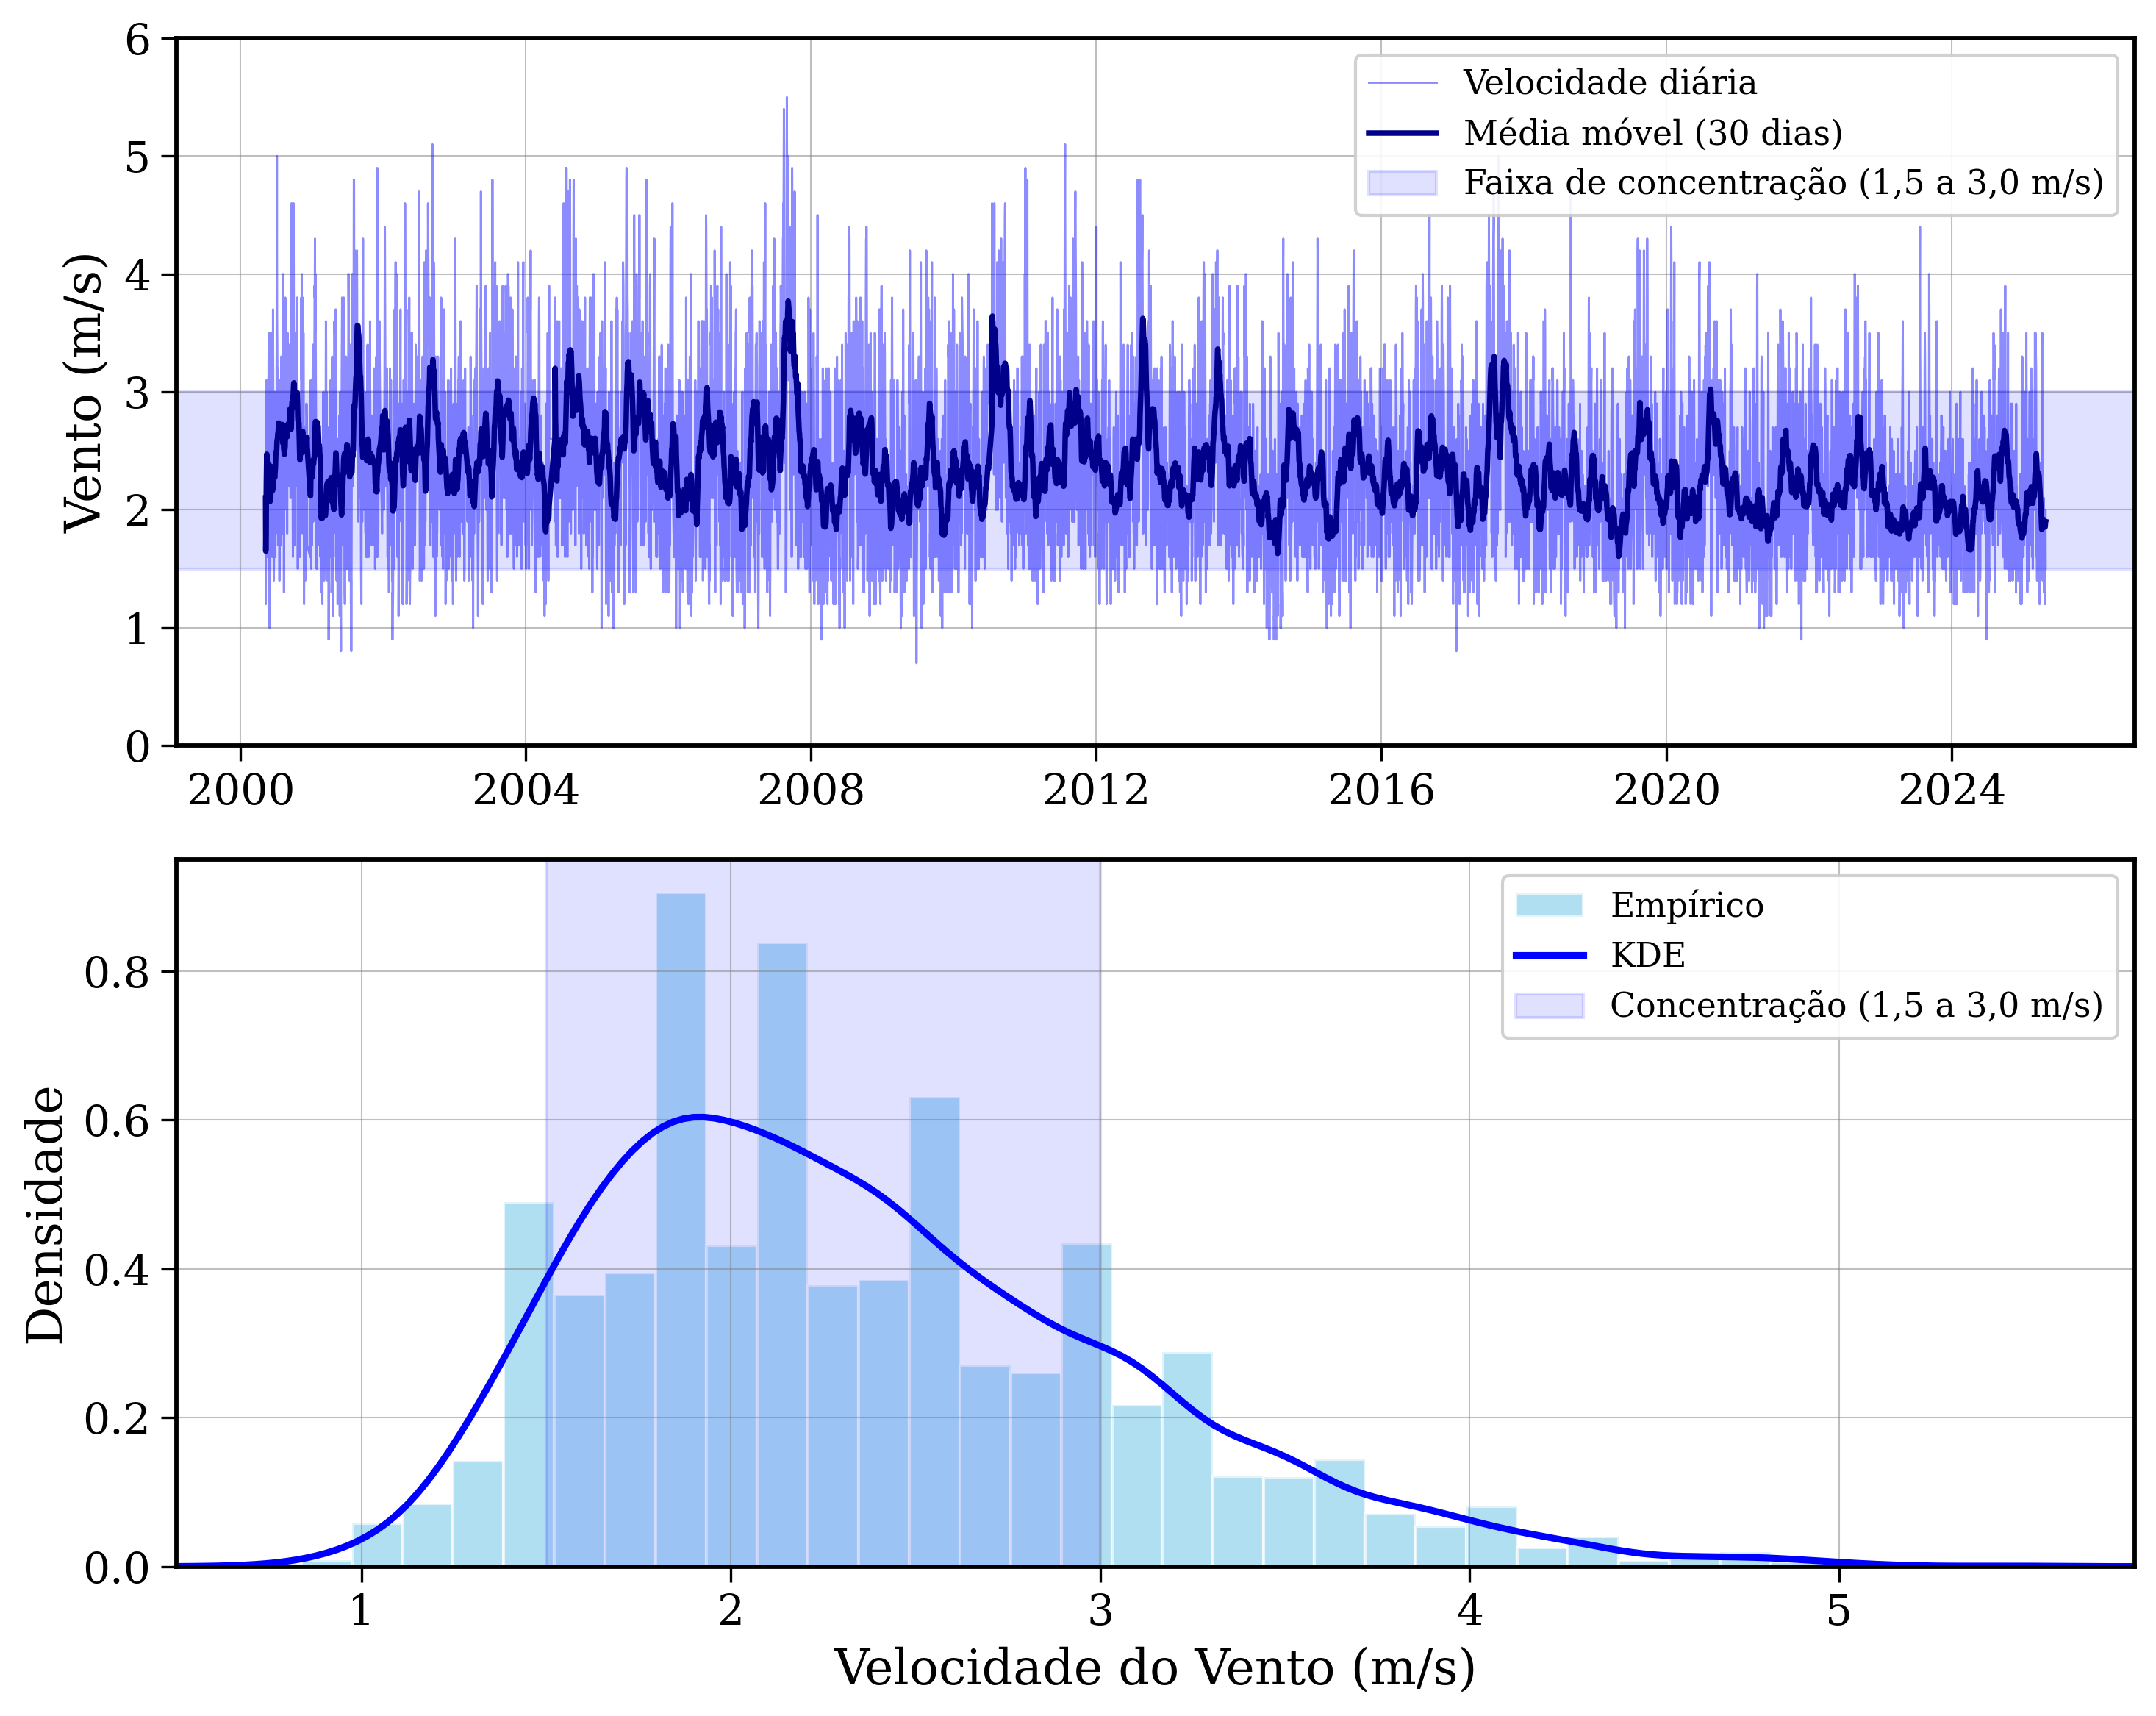

In [9]:
df_vento = df.dropna(subset=['vento_ms']).copy()
df_vento['data'] = pd.to_datetime(df_vento['data'])
df_vento = df_vento.sort_values('data')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), dpi=300)

# (a) Série Temporal
ax1.plot(df_vento['data'], df_vento['vento_ms'], color='blue', alpha=0.45, linewidth=0.7, label='Velocidade diária')
rolling_mean = df_vento.set_index('data')['vento_ms'].rolling('30D').mean()
ax1.plot(rolling_mean.index, rolling_mean.values, color='darkblue', linewidth=1.8, label='Média móvel (30 dias)')
ax1.axhspan(1.5, 3.0, color='blue', alpha=0.12, label='Faixa de concentração (1,5 a 3,0 m/s)')
ax1.set_ylabel('Vento (m/s)')
ax1.grid(True, linestyle='-', alpha=0.5, color='gray', linewidth=0.5)
ax1.set_ylim(0, 6.0)
ax1.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=11)

# (b) Histograma e Densidade
ax2.hist(df_vento['vento_ms'], bins=35, density=True, color='skyblue', edgecolor='white', alpha=0.65, label='Empírico')
sns.kdeplot(df_vento['vento_ms'], ax=ax2, color='blue', linewidth=2.2, label='KDE')
ax2.axvspan(1.5, 3.0, color='blue', alpha=0.12, label='Concentração (1,5 a 3,0 m/s)')
ax2.set_xlabel('Velocidade do Vento (m/s)')
ax2.set_ylabel('Densidade')
ax2.grid(True, linestyle='-', alpha=0.5, color='gray', linewidth=0.5)
ax2.set_xlim(0.5, 5.8)
ax2.set_ylim(bottom=0)
ax2.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=11)

plt.tight_layout()
plt.savefig('figura2_exploratoria_vento.png', dpi=300)
plt.show()

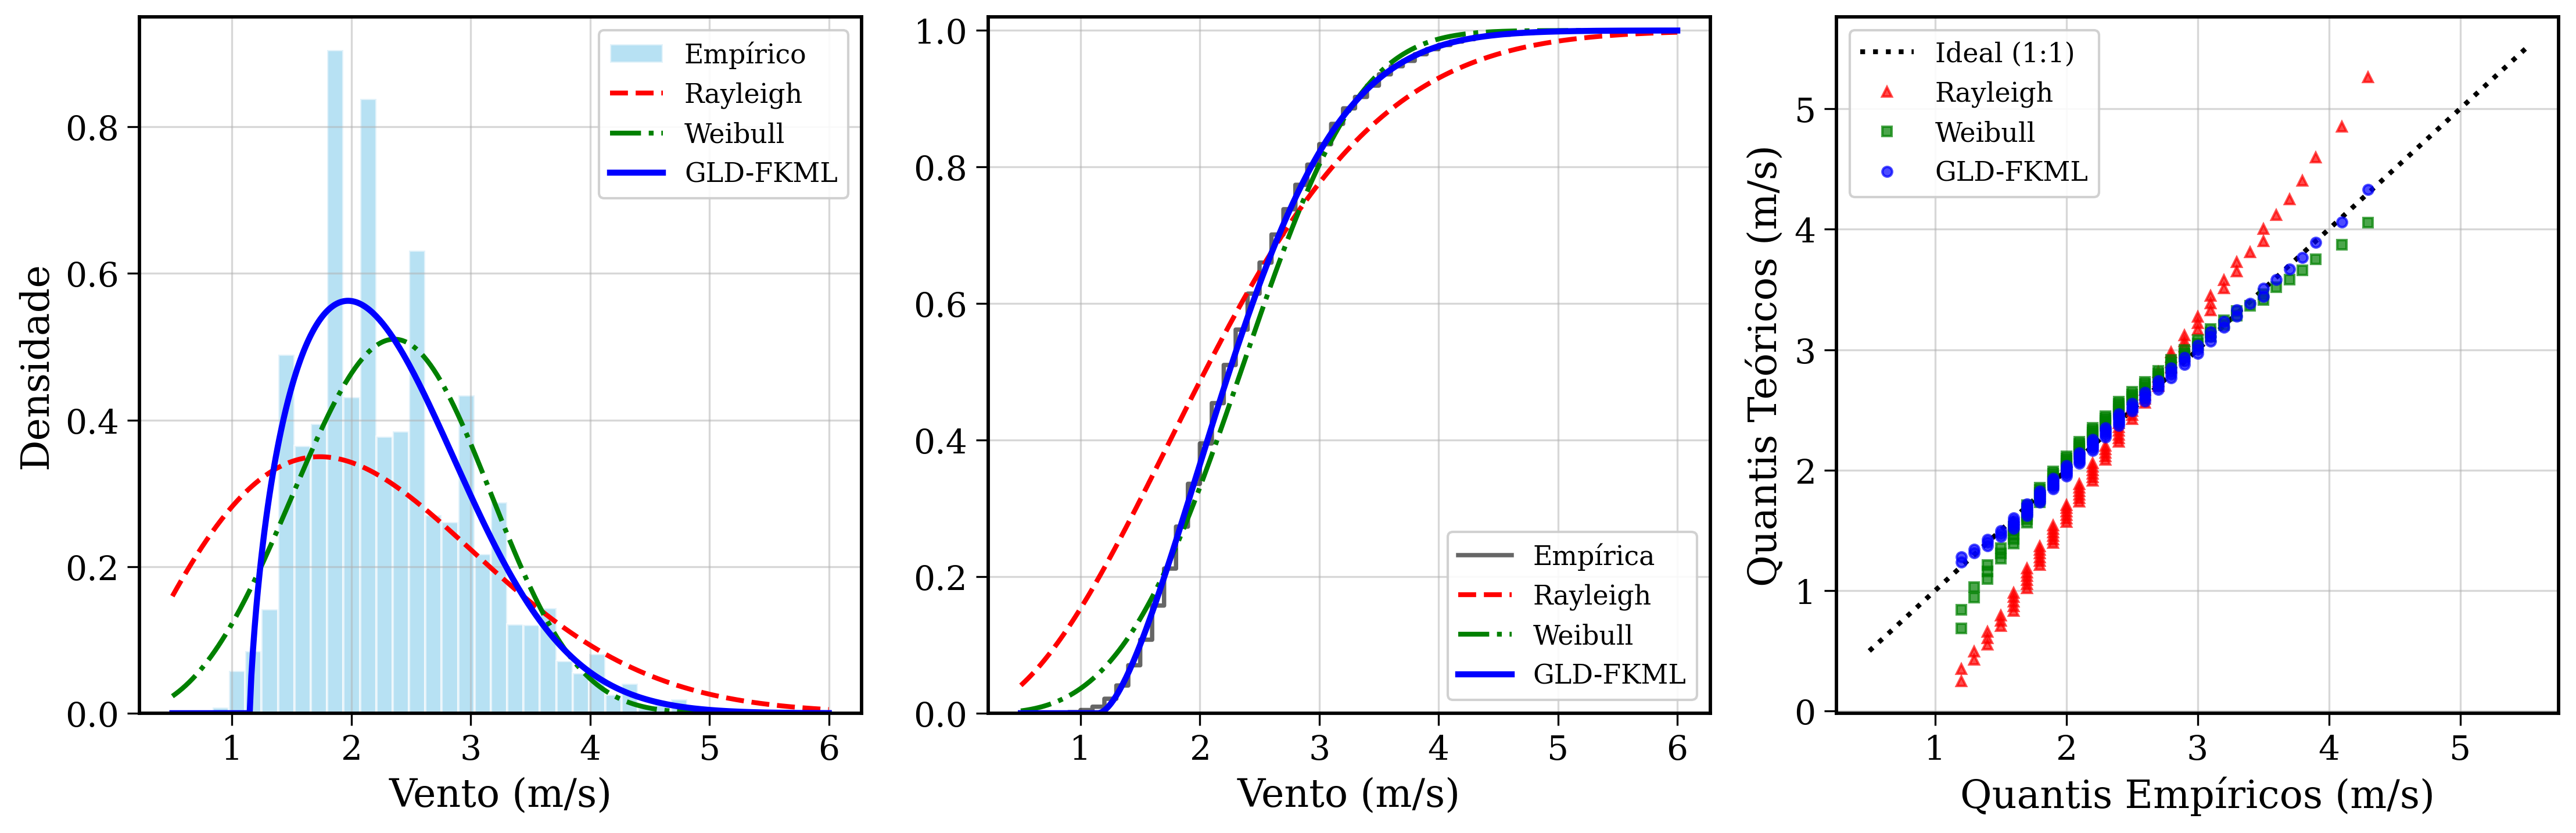

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)
x_grid = np.linspace(0.5, 6.0, 400)

# (a) Densidades
ax1 = axes[0]
ax1.hist(v, bins=35, density=True, color='skyblue', edgecolor='white', alpha=0.6, label='Empírico')
ax1.plot(x_grid, ray_dist.pdf(x_grid), color='red', linestyle='--', label='Rayleigh')
ax1.plot(x_grid, w_dist.pdf(x_grid), color='green', linestyle='-.', label='Weibull')
ax1.plot(x_grid, safe_gld_pdf(gld_v, x_grid), color='blue', linestyle='-', linewidth=2.5, label='GLD-FKML')
ax1.set_xlabel('Vento (m/s)')
ax1.set_ylabel('Densidade')
ax1.grid(True, linestyle='-', alpha=0.5)
ax1.set_ylim(bottom=0)
ax1.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)

# (b) CDF
ax2 = axes[1]
ax2.step(np.sort(v), np.arange(1, n + 1) / n, color='black', alpha=0.6, linewidth=1.8, where='post', label='Empírica')
ax2.plot(x_grid, ray_dist.cdf(x_grid), color='red', linestyle='--', label='Rayleigh')
ax2.plot(x_grid, w_dist.cdf(x_grid), color='green', linestyle='-.', label='Weibull')
ax2.plot(x_grid, safe_gld_cdf(gld_v, x_grid), color='blue', linestyle='-', linewidth=2.5, label='GLD-FKML')
ax2.set_xlabel('Vento (m/s)')
ax2.grid(True, linestyle='-', alpha=0.5)
ax2.set_ylim(0, 1.02)
ax2.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11, loc='lower right')

# (c) Q-Q Plot
ax3 = axes[2]
probs = np.linspace(0.01, 0.99, 100)
q_emp_100 = np.percentile(v, probs * 100)
ax3.plot([0.5, 5.5], [0.5, 5.5], color='black', linestyle=':', label='Ideal (1:1)')
ax3.plot(q_emp_100, ray_dist.ppf(probs), color='red', marker='^', ms=4, ls='none', alpha=0.7, label='Rayleigh')
ax3.plot(q_emp_100, w_dist.ppf(probs), color='green', marker='s', ms=4, ls='none', alpha=0.7, label='Weibull')
ax3.plot(q_emp_100, gld_v.ppf(probs), color='blue', marker='o', ms=4, ls='none', alpha=0.7, label='GLD-FKML')
ax3.set_xlabel('Quantis Empíricos (m/s)')
ax3.set_ylabel('Quantis Teóricos (m/s)')
ax3.grid(True, linestyle='-', alpha=0.5)
ax3.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11, loc='upper left')

plt.tight_layout()
plt.savefig('figura3_diagnosticos_vento.png', dpi=300)
plt.show()

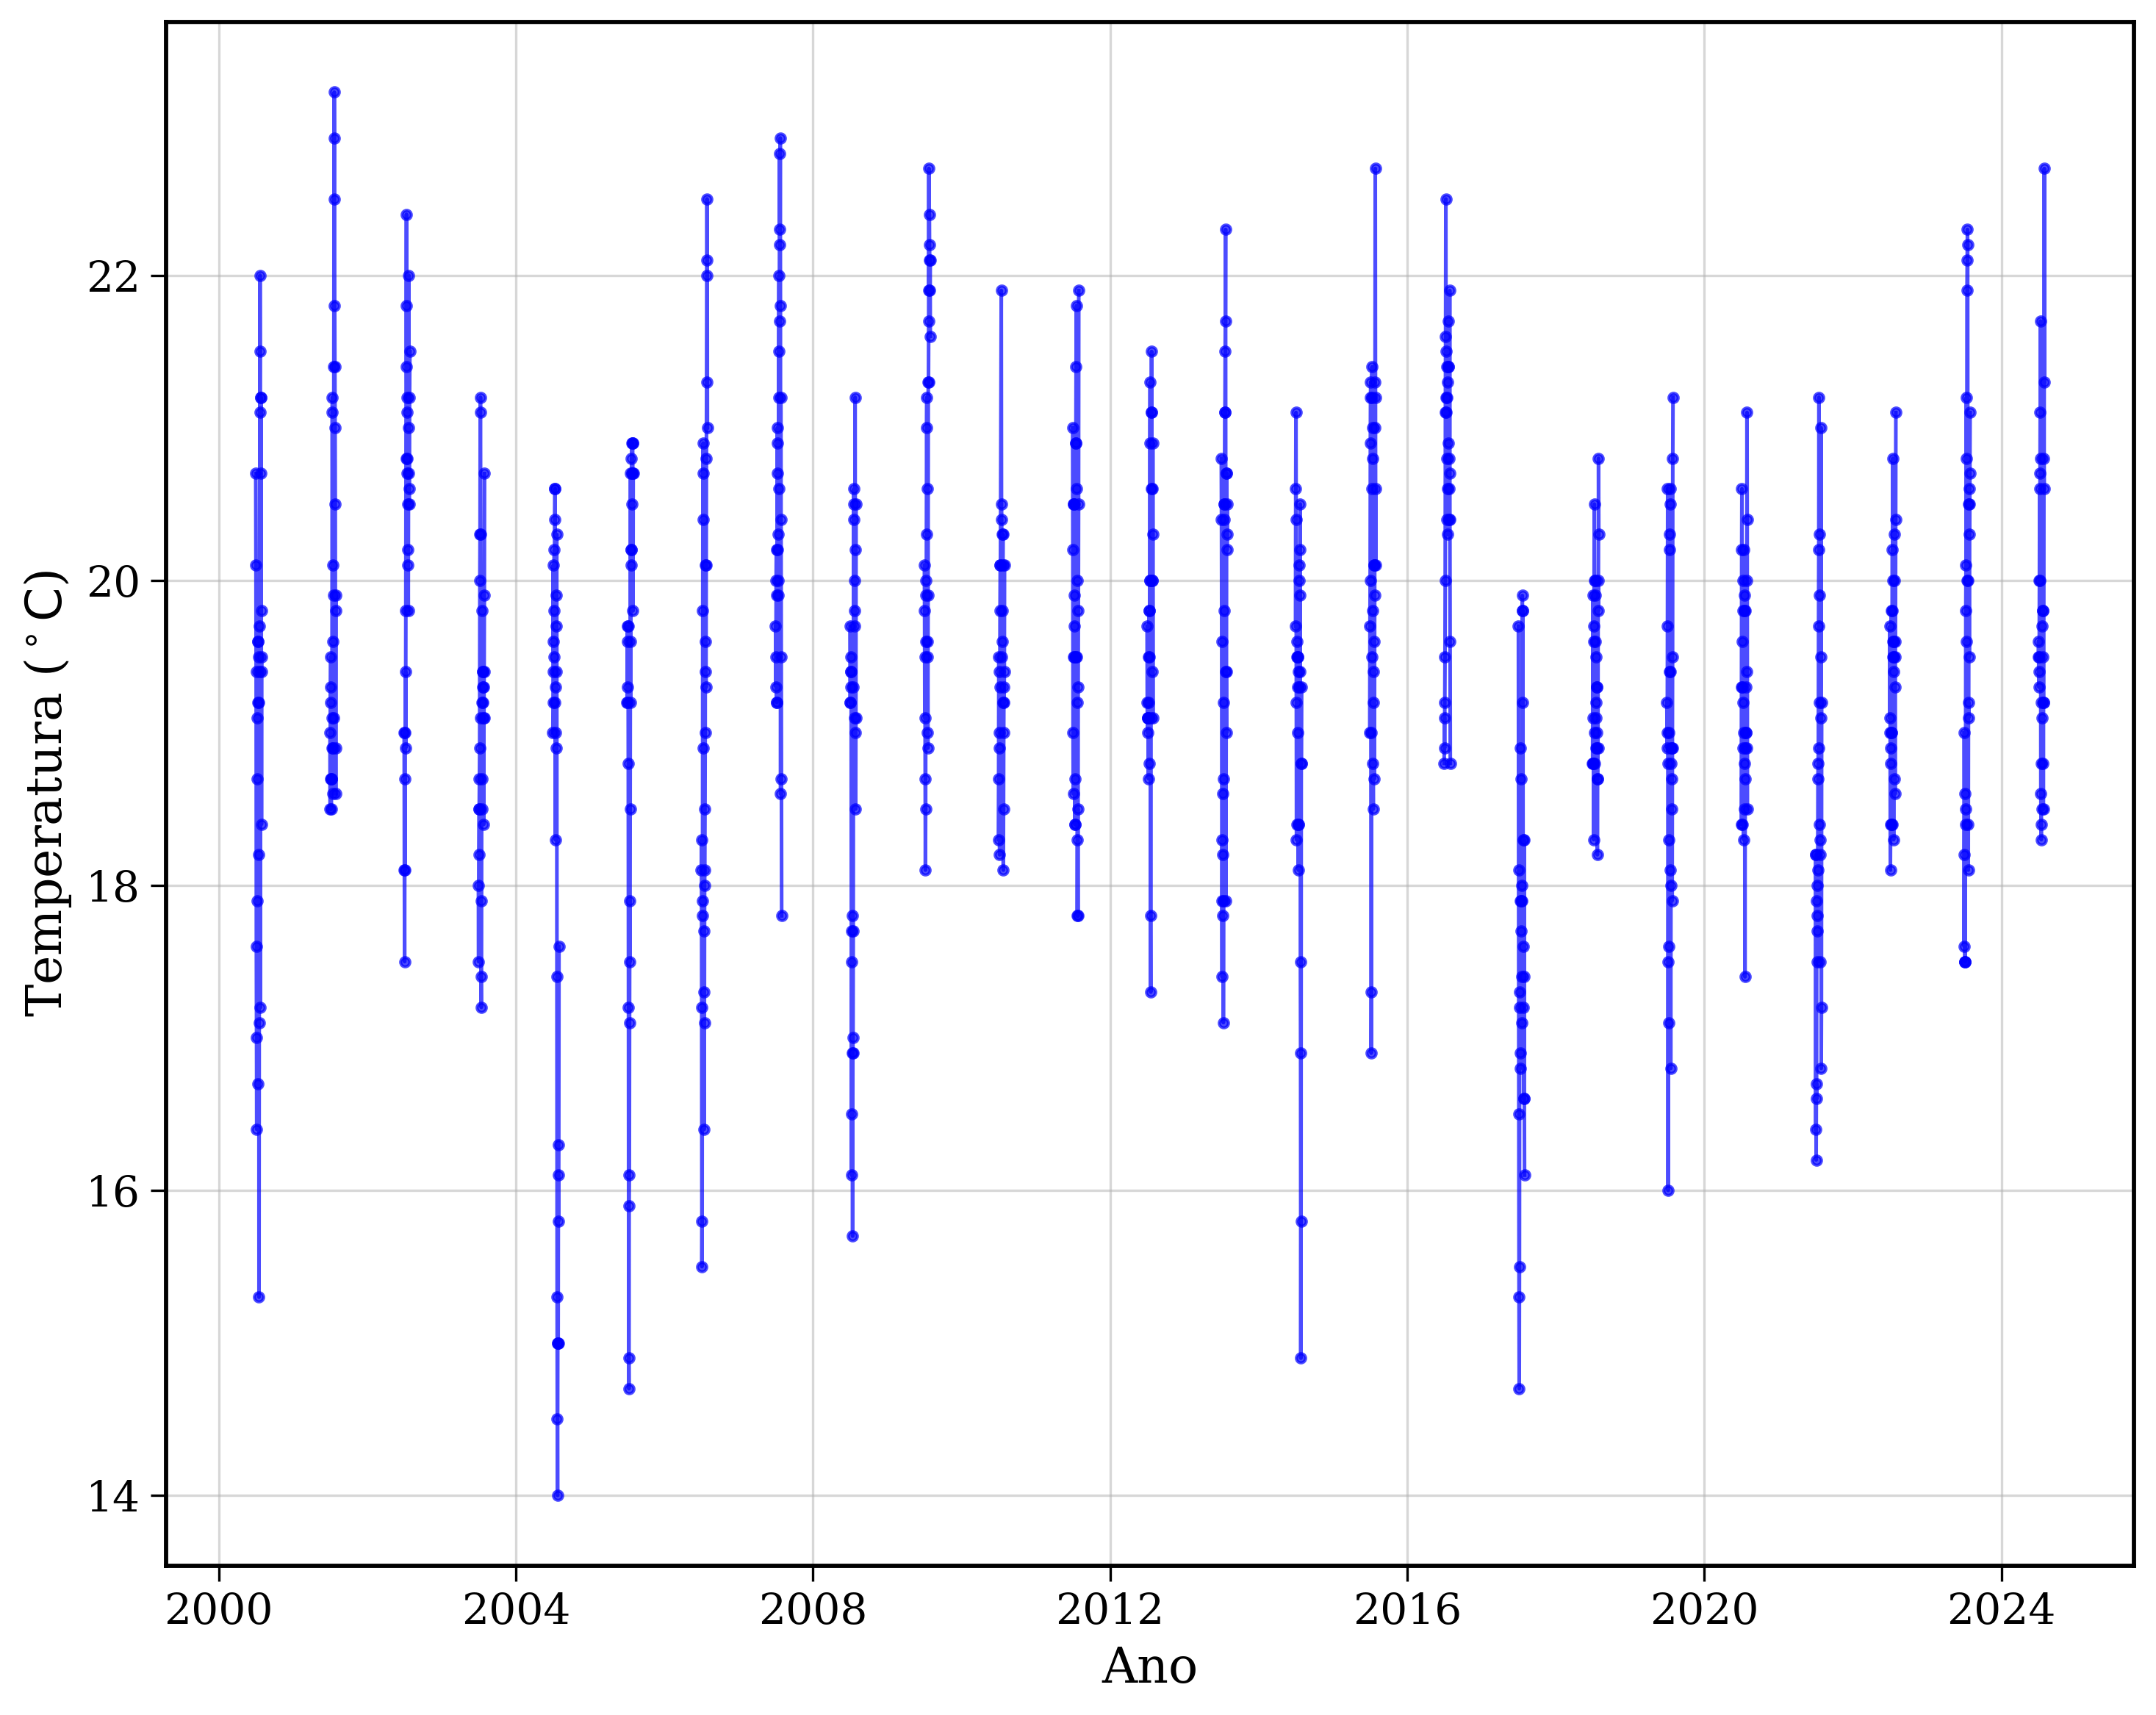

In [13]:
df['data'] = pd.to_datetime(df['data'])
df['mes'] = df['data'].dt.month
df['ano'] = df['data'].dt.year

df_temp = df.dropna(subset=['temperatura_c']).copy()
df_julho = df_temp[df_temp['mes'] == 7].sort_values('data')

fig, (ax2) = plt.subplots(1, 1, figsize=(10, 8), dpi=300)

# (a) Série Temporal de Julho
for ano in df_julho['ano'].unique():
    df_ano = df_julho[df_julho['ano'] == ano]
    ax2.plot(df_ano['data'], df_ano['temperatura_c'], color='blue', linewidth=1.2, marker='o', ms=3, alpha=0.7)

ax2.set_xlabel('Ano')
ax2.set_ylabel(r'Temperatura ($^\circ\mathrm{C}$)')
ax2.grid(True, linestyle='-', alpha=0.5)

plt.tight_layout()
plt.savefig('figura4_temperatura_sazonalidade.png', dpi=300)
plt.show()

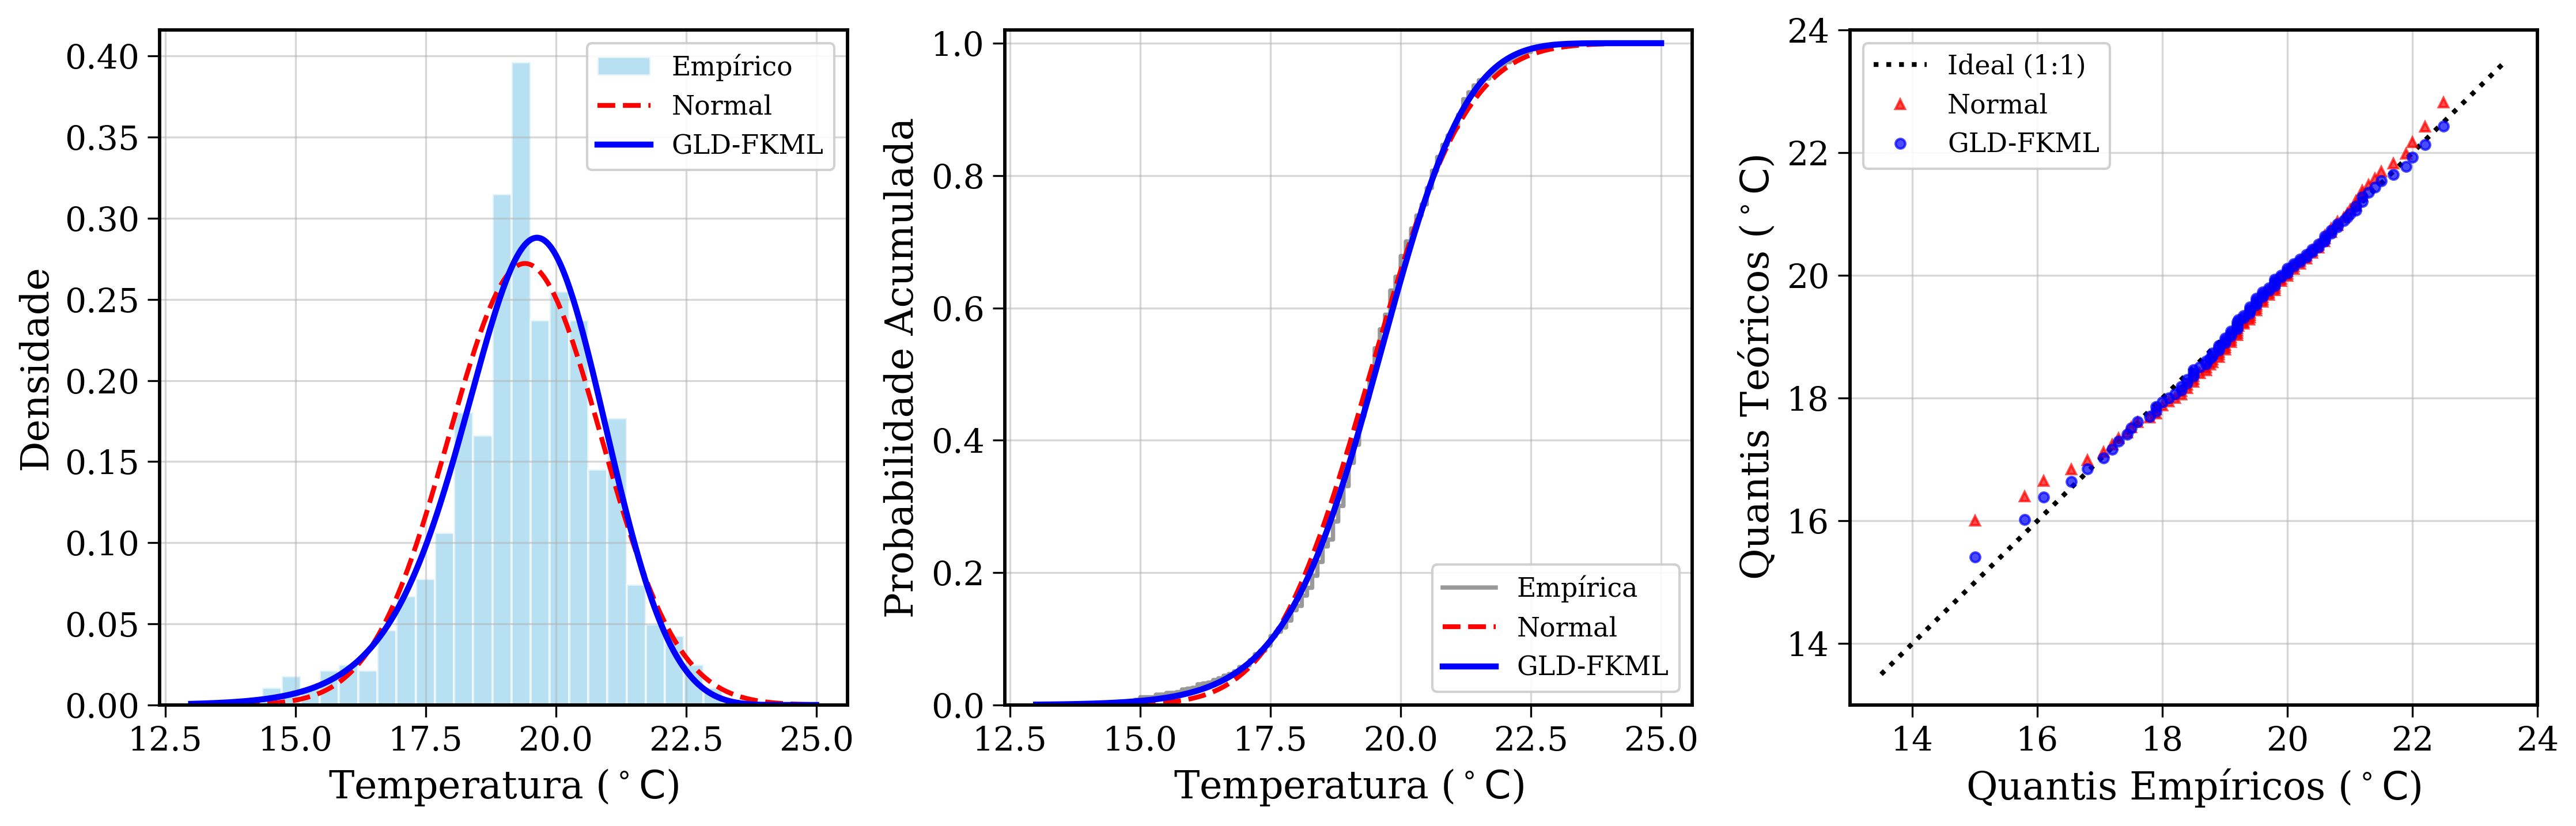

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)
x_grid_t = np.linspace(13.0, 25.0, 400)

t = df_julho['temperatura_c'].dropna().values
n_t = len(t)
probs = np.linspace(0.01, 0.99, 100)

# (a) Densidades
ax1 = axes[0]
ax1.hist(t, bins=25, density=True, color='skyblue', edgecolor='white', alpha=0.6, label='Empírico')
ax1.plot(x_grid_t, norm_dist.pdf(x_grid_t), color='red', linestyle='--', linewidth=2.0, label='Normal')
ax1.plot(x_grid_t, safe_gld_pdf(gld_t, x_grid_t), color='blue', linestyle='-', linewidth=2.5, label='GLD-FKML')
ax1.set_xlabel(r'Temperatura ($^\circ\mathrm{C}$)')
ax1.set_ylabel('Densidade')
ax1.grid(True, linestyle='-', alpha=0.5)
ax1.set_ylim(bottom=0)
ax1.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)

# (b) CDF
ax2 = axes[1]
ax2.step(np.sort(t), np.arange(1, n_t + 1) / n_t, color='gray', alpha=0.8, linewidth=1.8, where='post', label='Empírica')
ax2.plot(x_grid_t, norm_dist.cdf(x_grid_t), color='red', linestyle='--', linewidth=2.0, label='Normal')
ax2.plot(x_grid_t, safe_gld_cdf(gld_t, x_grid_t), color='blue', linestyle='-', linewidth=2.5, label='GLD-FKML')
ax2.set_xlabel(r'Temperatura ($^\circ\mathrm{C}$)')
ax2.set_ylabel('Probabilidade Acumulada')
ax2.grid(True, linestyle='-', alpha=0.5)
ax2.set_ylim(0, 1.02)
ax2.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11, loc='lower right')

# (c) Q-Q Plot
ax3 = axes[2]
q_emp_t100 = np.percentile(t, probs * 100)
ax3.plot([13.5, 23.5], [13.5, 23.5], color='black', linestyle=':', label='Ideal (1:1)')
ax3.plot(q_emp_t100, norm_dist.ppf(probs), color='red', marker='^', ms=4, ls='none', alpha=0.7, label='Normal')
ax3.plot(q_emp_t100, gld_t.ppf(probs), color='blue', marker='o', ms=4, ls='none', alpha=0.7, label='GLD-FKML')
ax3.set_xlabel(r'Quantis Empíricos ($^\circ\mathrm{C}$)')
ax3.set_ylabel(r'Quantis Teóricos ($^\circ\mathrm{C}$)')
ax3.grid(True, linestyle='-', alpha=0.5)
ax3.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11, loc='upper left')

plt.tight_layout()
plt.savefig('figura5_diagnosticos_temperatura.png', dpi=300)
plt.show()

In [21]:
t = df_julho['temperatura_c'].values
q_emp_t = np.percentile(t, [5, 50, 95])

def print_latex_row_t(nome, params, dist_cdf, dist_ppf):
    D_n, _ = stats.kstest(t, dist_cdf)
    deltas = dist_ppf([0.05, 0.50, 0.95]) - q_emp_t
    print(f"{nome} & {params} & {D_n:.4f} & {deltas[0]:+.4f} & {deltas[1]:+.4f} & {deltas[2]:+.4f} \\\\")

print("Desempenho comparativo dos modelos ajustados aos dados de temperatura de julho (°C):")
# Normal
loc_n, scale_n = stats.norm.fit(t)
norm_dist = stats.norm(loc=loc_n, scale=scale_n)
print_latex_row_t("Normal", 2, norm_dist.cdf, norm_dist.ppf)

# GLD-FKML
sol_t = GlamFKML().fit_lambdas(t)
if sol_t.success:
    gld_t = GlamFKML(*sol_t.x)
    print_latex_row_t("GLD-FKML", 4, lambda x: safe_gld_cdf(gld_t, x), gld_t.ppf)

Desempenho comparativo dos modelos ajustados aos dados de temperatura de julho (°C):
Normal & 2 & 0.0642 & +0.1632 & -0.0908 & +0.1203 \\
GLD-FKML & 4 & 0.0408 & +0.0247 & +0.0025 & -0.0575 \\
